# Import Libraries___

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

What is the total sales and profit?
Which category performs best?
What are monthly sales trends?
Which region generates the most revenue?
How do discounts affect profit?
Who are the top customers?

# Load DataSet___

In [2]:
data = pd.read_csv('Sample - Superstore.csv' , encoding='latin-1')
data.head() 

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Data Information___

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

# Data Handling___

In [4]:
data = data.drop(['Row ID', 'Order ID','Ship Date' , 'Ship Mode','Customer Name' , 'Country', 'City' , 'State' , 'Postal Code', 'Product ID','Sub-Category', 'Product Name' ,'Quantity'], axis=1)
data.head()

,Order Date,Customer ID,Segment,Region,Category,Sales,Discount,Profit
0,11/8/2016,CG-12520,Consumer,South,Furniture,261.9600,0.00,41.9136
1,11/8/2016,CG-12520,Consumer,South,Furniture,731.9400,0.00,219.5820
2,6/12/2016,DV-13045,Corporate,West,Office Supplies,14.6200,0.00,6.8714
3,10/11/2015,SO-20335,Consumer,South,Furniture,957.5775,0.45,-383.0310
4,10/11/2015,SO-20335,Consumer,South,Office Supplies,22.3680,0.20,2.5164


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Order Date   9994 non-null   str    
 1   Customer ID  9994 non-null   str    
 2   Segment      9994 non-null   str    
 3   Region       9994 non-null   str    
 4   Category     9994 non-null   str    
 5   Sales        9994 non-null   float64
 6   Discount     9994 non-null   float64
 7   Profit       9994 non-null   float64
dtypes: float64(3), str(5)
memory usage: 624.8 KB


In [17]:
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Month'] = data['Order Date'].dt.month
data['Month'] = data['Month'].map({1:'January', 2:'February', 3:'March', 4:'April', 5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October', 11:'November', 12:'December'})

In [19]:
data.dropna(inplace=True)

In [20]:
data.head()

,Order Date,Customer ID,Segment,Region,Category,Sales,Discount,Profit,Month
0,2016-11-08,CG-12520,Consumer,South,Furniture,261.9600,0.00,41.9136,November
1,2016-11-08,CG-12520,Consumer,South,Furniture,731.9400,0.00,219.5820,November
2,2016-06-12,DV-13045,Corporate,West,Office Supplies,14.6200,0.00,6.8714,June
3,2015-10-11,SO-20335,Consumer,South,Furniture,957.5775,0.45,-383.0310,October
4,2015-10-11,SO-20335,Consumer,South,Office Supplies,22.3680,0.20,2.5164,October


In [21]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Order Date   9994 non-null   datetime64[us]
 1   Customer ID  9994 non-null   str           
 2   Segment      9994 non-null   str           
 3   Region       9994 non-null   str           
 4   Category     9994 non-null   str           
 5   Sales        9994 non-null   float64       
 6   Discount     9994 non-null   float64       
 7   Profit       9994 non-null   float64       
 8   Month        9994 non-null   str           
dtypes: datetime64[us](1), float64(3), str(5)
memory usage: 702.8 KB


# Visualization___

# 1. What is the total sales and profit?

In [27]:
Total_Sales = data['Sales'].sum()
Total_profit = data['Profit'].sum()
print('Total Sales: ', Total_Sales)
print('Total Profit: ', Total_profit)

Total Sales:  2297200.8603
Total Profit:  286397.0217


# 2. Which category performs best?

C:\Users\legen\AppData\Local\Temp\ipykernel_29900\1082589227.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values , palette='Set1')


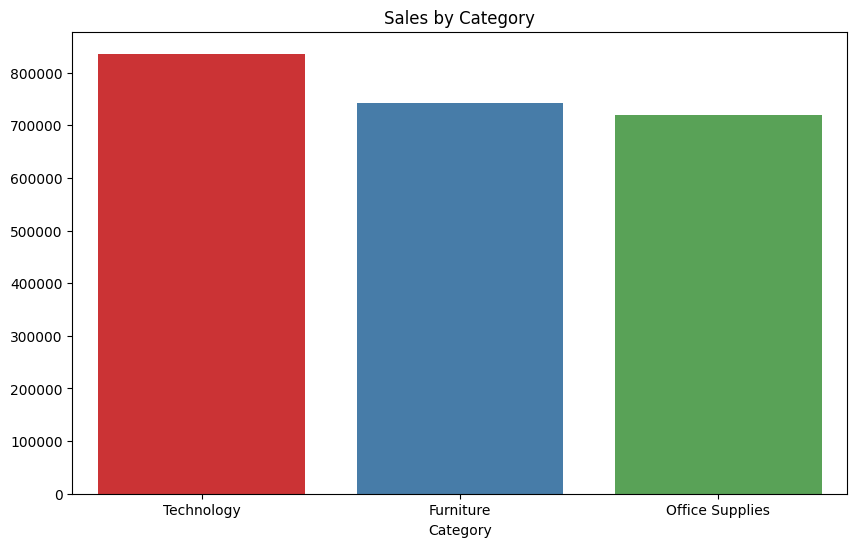

In [38]:

# Sales by Category
category_sales = data.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=category_sales.index, y=category_sales.values , palette='Set1')
plt.title("Sales by Category")
plt.show()


# 3 . What are monthly sales trends?

C:\Users\legen\AppData\Local\Temp\ipykernel_29900\4244876507.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Monthly_Sales.index, y=Monthly_Sales.values , palette='Set2')


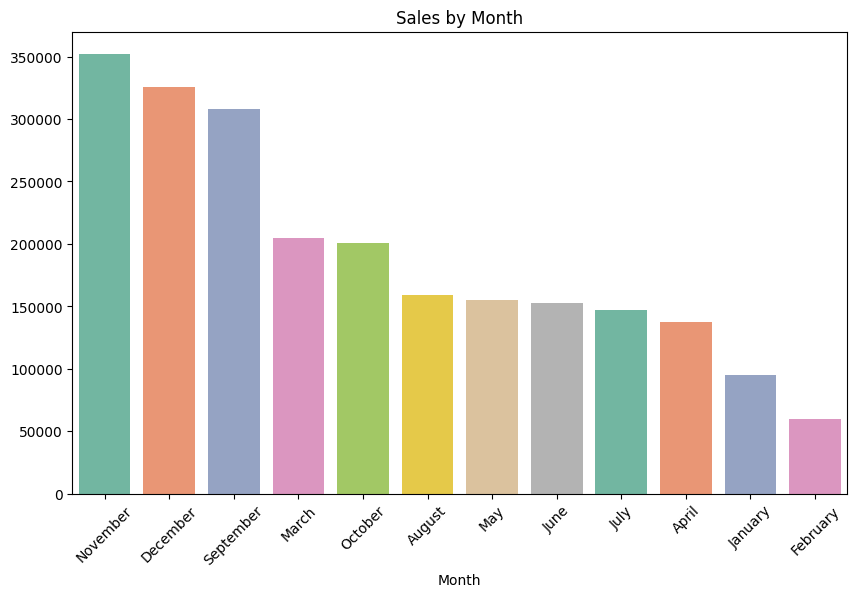

In [ ]:
# Sales By Monthly...

Monthly_Sales = data.groupby(('Month'))['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=Monthly_Sales.index, y=Monthly_Sales.values , palette='Set2')
plt.title("Sales by Month")
plt.xticks(rotation=45)
plt.show()


# 4 . Who are the top customers?

C:\Users\legen\AppData\Local\Temp\ipykernel_29900\3743209996.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Top_Customers.index[:10], y=Top_Customers.values[:10] , palette='Set3')


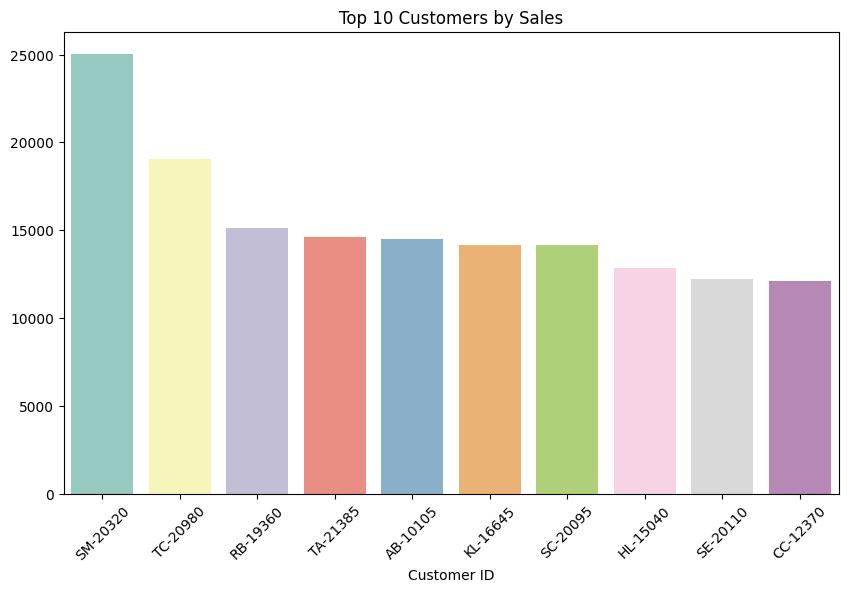

In [41]:
Top_Customers = data.groupby('Customer ID')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=Top_Customers.index[:10], y=Top_Customers.values[:10] , palette='Set3')
plt.title("Top 10 Customers by Sales")
plt.xticks(rotation=45)
plt.show()

# 5. How do discounts affect profit?

<Axes: xlabel='Discount', ylabel='Profit'>

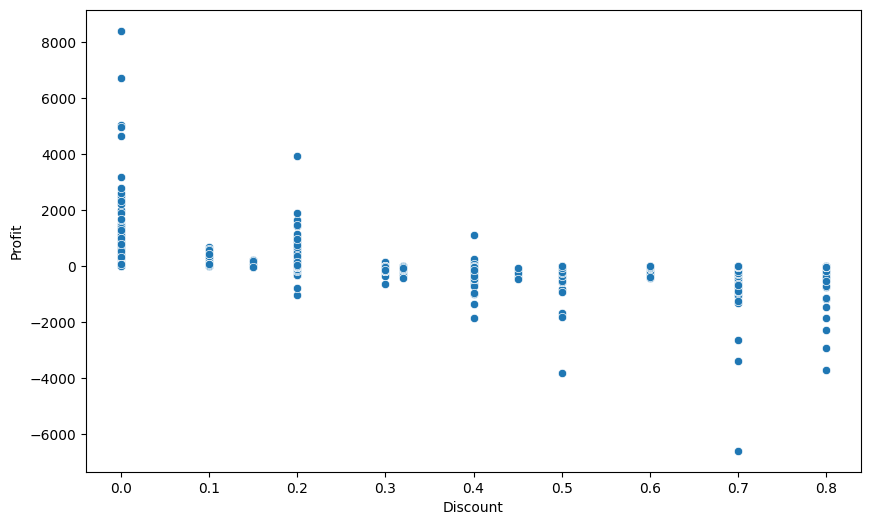

In [44]:
plt.figure(figsize=(10,6))
sns.scatterplot(data = data , x = 'Discount' , y = 'Profit')

# 6. Which region generates the most revenue?

C:\Users\legen\AppData\Local\Temp\ipykernel_29900\4175195571.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Region_Sales.index, y=Region_Sales.values , palette='Set1')


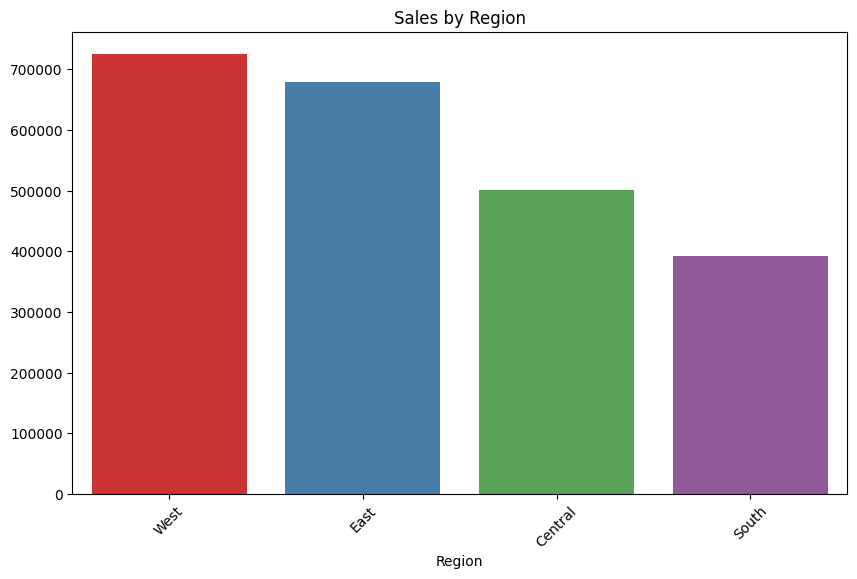

In [46]:
Region_Sales = data.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=Region_Sales.index, y=Region_Sales.values , palette='Set1')
plt.title("Sales by Region")
plt.xticks(rotation=45)
plt.show()